<a href="https://colab.research.google.com/github/ohyamaty/test/blob/main/%E6%9D%B1%E5%A4%A7%E3%80%8C%E6%83%85%E5%A0%B1%E3%80%8D2026_%E7%AC%AC10%E5%9B%9E_3%E7%AB%A0%E8%AA%B2%E9%A1%8C_%E5%9B%9E%E7%AD%94%E5%85%A5%E3%82%8A.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ①グラフで「偏り」とエントロピーの関係を見る

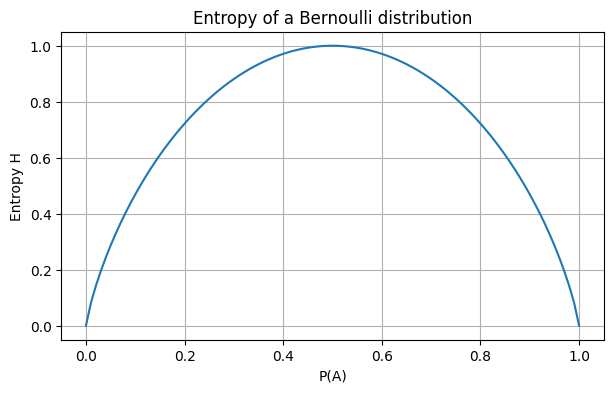

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def entropy(p):
    p = np.array(p)
    p = p[p > 0]
    return np.sum(p * np.log2(1/p))

ps = np.linspace(0, 1, 101)
Hs = [entropy([p, 1-p]) for p in ps]

plt.figure(figsize=(7, 4))
plt.plot(ps, Hs)
plt.xlabel("P(A)")
plt.ylabel("Entropy H")
plt.title("Entropy of a Bernoulli distribution")
plt.grid(True)
plt.show()

1. エントロピーが最大になるのは P(A) がいくつのときか？式とともに示せ．
2. P(A)=0 や P(A)=1 のとき，なぜエントロピーは0になるのか？エントロピーの式に着目して答えよ．
3. P(A)=0.5 のとき，なぜ最も不確実なのか？

# 課題① グラフで「偏り」とエントロピーの関係を見る

ベルヌーイ分布を考える．ある事象Aが起こる確率を $p$ とすると，もう一方の事象Bが起こる確率は $1-p$ である．

$$
P(A)=p,\quad P(B)=1-p
$$

このときのエントロピーは，次の式で表される．

$$
H(p)=p\log_2\frac{1}{p}+(1-p)\log_2\frac{1}{1-p}
$$

または，次のようにも書ける．

$$
H(p)=-p\log_2p-(1-p)\log_2(1-p)
$$

## 1. エントロピーが最大になるのはいつか

エントロピーが最大になるのは，次のときである．

$$
P(A)=0.5
$$

このとき，

$$
P(A)=0.5,\quad P(B)=0.5
$$

であり，AとBのどちらも同じ確率で起こる．

エントロピーを計算すると，次のようになる．

$$
H(0.5)
=0.5\log_2\frac{1}{0.5}+0.5\log_2\frac{1}{0.5}
$$

$$
=0.5\log_2 2+0.5\log_2 2
$$

$$
=0.5+0.5=1
$$

したがって，エントロピーの最大値は，次の通りである．

$$
1 \text{ bit}
$$

## 2. $P(A)=0$ や $P(A)=1$ のとき，なぜエントロピーは0になるのか

たとえば，

$$
P(A)=1,\quad P(B)=0
$$

の場合，Aが必ず起こり，Bは絶対に起こらない．

このとき，結果は事前に完全に分かっているため，不確実性はない．

エントロピーの式に $p=1$ を入れると，次のようになる．

$$
1\cdot \log_2\frac{1}{1}=1\cdot \log_2 1=0
$$

一方，確率0の項は，次のような形になる．

$$
0\cdot \log_2\frac{1}{0}
$$

このままでは計算しにくいが，エントロピーでは，確率0の項は0として扱う．

これは，コードでも次のように，確率0の項を計算から除外していることに対応する．

```python
p = p[p > 0]
```

したがって，

$$
P(A)=0
$$

または，

$$
P(A)=1
$$

のとき，結果は完全に予測できるため，エントロピーは0になる．

## 3. $P(A)=0.5$ のとき，なぜ最も不確実なのか

$$
P(A)=0.5,\quad P(B)=0.5
$$

のとき，AとBは同じ確率で起こる．

つまり，Aの方が起こりやすいとも，Bの方が起こりやすいとも言えない．

そのため，どちらが起こるかを最も予測しにくい．

したがって，このとき不確実性が最大となり，エントロピーも最大になる．

# ②文字列のエントロピーを計算する

In [ ]:
from collections import Counter

texts = {
    "同じ文字だけ": "AAAAAAAAAA",
    "2種類が半々": "AAAAABBBBB",
    }

def entropy_from_text(text):
    counts = Counter(text)
    total = len(text)
    p = np.array(list(counts.values())) / total
    return entropy(p), counts

for name, text in texts.items():
    H, counts = entropy_from_text(text)
    print(name)
    print("文字数:", len(text))
    print("出現回数:", counts)
    print("1文字あたりエントロピー:", H)
    print()

1. 上記コードにおける"texts"を様々に作り変えてみて，エントロピーがどのように変わるか観察せよ．（たとえば，文字の種類が多い文字列にするとエントロピーはどうなるか？文字の長さを変えると？など）

2. エントロピーが高い文字列は，圧縮しやすいか？しにくいか？


# 課題② 文字列のエントロピーを計算する

文字列のエントロピーは，その文字列に含まれる各文字の出現確率から計算できる．

たとえば，次のように `texts` を作り変えることで，文字の種類や偏りによってエントロピーがどのように変わるかを確認できる．

```python
texts = {
    "同じ文字だけ": "AAAAAAAAAA",
    "2種類が半々": "AAAAABBBBB",
    "10種類が1回ずつ": "ABCDEFGHIJ",
    "偏りが大きい": "AAAAAAAABC",
    "文字数が長いが比率は同じ": "AAAAAAAAAABBBBBBBBBB",
}
```

## 1. 同じ文字だけの場合

たとえば，次の文字列を考える．

```text
AAAAAAAAAA
```

この文字列では，Aしか出てこない．

したがって，次のように表せる．

$$
P(A)=1
$$

次に出る文字は必ずAだと分かっているため，不確実性はない．

そのため，エントロピーは0になる．

## 2. 2種類が半々の場合

たとえば，次の文字列を考える．

```text
AAAAABBBBB
```

この文字列では，AとBが5回ずつ出てくる．

したがって，次のように表せる．

$$
P(A)=0.5,\quad P(B)=0.5
$$

AとBのどちらが出るかは，同じ文字だけの場合よりも予測しにくい．

このときの1文字あたりのエントロピーは，次の通りである．

$$
H=1 \text{ bit}
$$

## 3. 文字の種類が多い場合

たとえば，次の文字列を考える．

```text
ABCDEFGHIJ
```

この文字列では，10種類の文字が1回ずつ出てくる．

それぞれの文字の確率は，次の通りである．

$$
\frac{1}{10}
$$

文字の種類が多く，しかも出現確率が均等に近いほど，次にどの文字が出るかを予測しにくくなる．

したがって，エントロピーは高くなる．

この場合，エントロピーは次のようになる．

$$
H=\log_2 10 \approx 3.32 \text{ bit}
$$

## 4. 文字数を変えるとどうなるか

このコードで計算しているのは，文字列全体のエントロピーではなく，1文字あたりのエントロピーである．

たとえば，次の2つを比べる．

```text
AAAAABBBBB
```

```text
AAAAAAAAAABBBBBBBBBB
```

前者は10文字で，AとBが5文字ずつである．

後者は20文字で，AとBが10文字ずつである．

どちらも，次のように表せる．

$$
P(A)=0.5,\quad P(B)=0.5
$$

したがって，1文字あたりのエントロピーは同じになる．

つまり，単に文字列を長くしただけでは，出現確率の比率が同じなら，1文字あたりのエントロピーは変わらない．

ただし，文字列全体としての情報量は，文字数が多いほど大きくなる．

## 5. エントロピーが高い文字列は圧縮しやすいか，しにくいか

一般に，エントロピーが高い文字列は圧縮しにくい．

エントロピーが高いということは，文字の出現がばらばらで，次にどの文字が出るかを予測しにくいということである．

たとえば，次の文字列は規則性が強い．

```text
AAAAAAAAAA
```

これは，次のように短く表せる．

```text
Aが10回
```

したがって，圧縮しやすい．

一方，次のような文字列は，いろいろな文字が均等に出てくる．

```text
ABCDEFGHIJ
```

このような文字列は，単純な規則で短く表しにくい．

したがって，圧縮しにくい．

まとめると，次のようになる．

- エントロピーが低い文字列は，偏りや規則性があるため圧縮しやすい．
- エントロピーが高い文字列は，予測しにくいため圧縮しにくい．

# ③天気予報のエントロピー

In [ ]:
weather_patterns = {
    "地域A": [1/3, 1/3, 1/3],
    "地域B": [0.8, 0.1, 0.1],
    "地域C": [0.5, 0.5, 0.0],
}

for name, p in weather_patterns.items():
    print(name, "H =", entropy(p))

晴れ，曇り，雨の3種類だけ考えるとき，
1. どの地域の天気が最も予測しにくいか？
2. 「雨が降るかどうか」だけに注目すると，エントロピーはどう変わるか？実際にコードを書き換えて試してみよ
3. 天気予報が「ほぼ晴れ」と言えるとき，情報の不確実性は大きいか？小さいか？

# 課題③ 天気予報のエントロピー

ここでは，天気を次の3種類だけで考える．

```text
晴れ，曇り，雨
```

与えられた分布は，次の通りである．

```python
weather_patterns = {
    "地域A": [1/3, 1/3, 1/3],
    "地域B": [0.8, 0.1, 0.1],
    "地域C": [0.5, 0.5, 0.0],
}
```

ここで，それぞれのリストは，次の順番で確率を表している．

```text
[晴れの確率，曇りの確率，雨の確率]
```

## 1. どの地域の天気が最も予測しにくいか

最も予測しにくいのは，地域Aである．

地域Aでは，次のようになっている．

$$
P(\text{晴れ})=\frac{1}{3}
$$

$$
P(\text{曇り})=\frac{1}{3}
$$

$$
P(\text{雨})=\frac{1}{3}
$$

晴れ，曇り，雨がすべて同じ確率で起こるため，どの天気になるかを最も予測しにくい．

したがって，地域Aのエントロピーが最も大きい．

地域Aのエントロピーは，次の通りである．

$$
H(A)=3×\frac{1}{3} \log_2 3 =\log_2 3 \approx 1.585
$$

一方，地域Bは晴れに大きく偏っているため，ある程度予測しやすい．
$$
H(B) \approx 0.922
$$

地域Cは晴れか曇りの2択であり，雨は起こらない．
$$
H(C) =1
$$

そのため，地域Aよりもエントロピーは小さい．

| 地域 | 晴れ，曇り，雨の分布 | エントロピー |
|---|---|---:|
| 地域A | [1/3, 1/3, 1/3] | 約 1.585 bit |
| 地域B | [0.8, 0.1, 0.1] | 約 0.922 bit |
| 地域C | [0.5, 0.5, 0.0] | 1.000 bit |

## 2. 「雨が降るかどうか」だけに注目するとどうなるか

「晴れ，曇り，雨」の3分類ではなく，次の2分類に変える．

```text
雨
雨ではない
```

このとき，地域ごとの分布は次のようになる．

地域Aでは，次のようになる．

$$
P(\text{雨})=\frac{1}{3}
$$

$$
P(\text{雨ではない})=\frac{2}{3}
$$

地域Bでは，次のようになる．

$$
P(\text{雨})=0.1
$$

$$
P(\text{雨ではない})=0.9
$$

地域Cでは，次のようになる．

$$
P(\text{雨})=0
$$

$$
P(\text{雨ではない})=1
$$

### 「雨が降るかどうか」に変換するコード

```python
weather_patterns = {
    "地域A": [2/3, 1/3],
    "地域B": [0.9, 0.1],
    "地域C": [1, 0],
}

for name, p in weather_patterns.items():
    print(name, "H =", entropy(p))
```

出力は，およそ次のようになる．

```text
地域A [0.333..., 0.666...] H = 0.918...
地域B [0.1, 0.9] H = 0.469...
地域C [0.0, 1.0] H = 0.0
```

| 地域 | 雨 | 雨ではない | エントロピー |
|---|---:|---:|---:|
| 地域A | 1/3 | 2/3 | 約 0.918 bit |
| 地域B | 0.1 | 0.9 | 約 0.469 bit |
| 地域C | 0.0 | 1.0 | 0.000 bit |

地域Aでは，雨が降る可能性も，降らない可能性もあるため，不確実性が残る．

地域Bでは，雨が降らない可能性が高いため，地域Aより不確実性は小さい．

地域Cでは，雨が降る確率が0である．

つまり，必ず雨ではない．

したがって，「雨が降るかどうか」に関する不確実性はなく，エントロピーは0になる．

## 3. 天気予報が「ほぼ晴れ」と言えるとき，情報の不確実性は大きいか，小さいか

情報の不確実性は小さい．

たとえば地域Bでは，次のようになっている．

$$
P(\text{晴れ})=0.8
$$

これは，晴れになる確率が高いということである．

この場合，天気はかなり予測しやすい．

したがって，不確実性は小さく，エントロピーも小さくなる．

逆に，晴れ，曇り，雨がすべて同じ確率で起こる地域Aでは，どの天気になるか予測しにくい．

そのため，不確実性が大きく，エントロピーも大きい．

## まとめ

エントロピーは，結果の予測しにくさを表す．

確率分布が均等に近いほど，どの結果が起こるか分かりにくく，エントロピーは大きくなる．

確率分布が特定の結果に偏るほど，結果を予測しやすく，エントロピーは小さくなる．

結果が必ず1つに決まっている場合，エントロピーは0になる．